In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import xarray as xr
import numpy as np
from distributed import Client, LocalCluster
import dask
import pickle
import os
from scipy.stats import linregress
from matplotlib.lines import Line2D
from scipy.stats import linregress
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
import joblib 
import time
import emcee
from matplotlib.ticker import FuncFormatter
import numpy as np
import pickle
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec
import corner #
from sklearn.model_selection import train_test_split
import gpflow 
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import KFold
from scipy.stats import linregress
import string
import pprint

2026-04-09 11:12:55.026067: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 11:12:57.841674: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-09 11:13:17.792904: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/glade/work/mckenna/conda_envs/esem/lib/python3.10/site-packages/gpf

## Loadings needed to use LaTex

In [2]:
# Get the current PATH
original_path = os.environ.get('PATH', '')
latex_path = '/glade/u/apps/casper/24.12/spack/opt/spack/texlive/20240312/gcc/12.4.0/nm7e/bin/x86_64-linux' 
# Prepend the LaTeX path to the system's PATH
# We prepend it to make sure it's found first.
os.environ['PATH'] = latex_path + os.pathsep + original_path
plt.rcParams['text.usetex'] = True

## Paths for saving/loading

In [3]:
fig_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
pre_path = '/glade/u/home/mckenna/work/ppe_pre/'

# Read in pickle file

In [11]:
with open(f"/glade/u/home/mckenna/work/msp1_all_forcings_v2.pkl", 'rb') as f:
    original_dict = pickle.load(f)

In [12]:
# --- 1. Setup: Create a placeholder for original dictionary ---
keys = list(original_dict.keys())

print(f"Original dictionary has {len(original_dict)} keys.")
print("-" * 30)

# --- 2. Define the keys for the special groups ---
control_key = 'msp1_00'
denial_keys = {'msp1_51', 'msp1_52', 'msp1_53'}

# The only keys to exclude from the main analysis dictionary are the denial runs.
keys_to_exclude_from_all = denial_keys

# --- 3. Create the `all_dict` (main PPE runs + Control) ---
# This dictionary will contain everything EXCEPT the denial runs.
all_dict = {
    key: value for key, value in original_dict.items() 
    if key not in keys_to_exclude_from_all
}

print(f"Created 'all_dict' with {len(all_dict)} keys (PPE + Control).")
# Verification:
print(f"  - Is 'msp1_00' in all_dict? {'msp1_00' in all_dict}")
print(f"  - Is 'msp1_50' in all_dict? {'msp1_50' in all_dict}")
print(f"  - Is 'msp1_51' in all_dict? {'msp1_51' in all_dict}")
print("-" * 30)

# --- 4. Create the `cntl_dict` ---
# This dictionary will still be created to isolate the control run for use as synthetic truth.
if control_key in original_dict:
    cntl_dict = {control_key: original_dict[control_key]}
    print(f"Created 'cntl_dict' with 1 key:")
    #pprint.pprint(cntl_dict)
else:
    cntl_dict = {}
    print(f"Warning: Control key '{control_key}' not found in original dictionary.")
print("-" * 30)

# --- 5. Create the `denial_dict` ---
# This remains the same, collecting only the denial runs.
denial_dict = {
    key: value for key, value in original_dict.items() 
    if key in denial_keys
}

print(f"Created 'denial_dict' with {len(denial_dict)} keys:")
#pprint.pprint(denial_dict)
print("-" * 30)

Original dictionary has 54 keys.
------------------------------
Created 'all_dict' with 51 keys (PPE + Control).
  - Is 'msp1_00' in all_dict? True
  - Is 'msp1_50' in all_dict? True
  - Is 'msp1_51' in all_dict? False
------------------------------
Created 'cntl_dict' with 1 key:
------------------------------
Created 'denial_dict' with 3 keys:
------------------------------


# Extract relevant data and create dataframes

In [42]:
source_dict = all_dict

# --- Step 1: Define the control member name and extract its data ---
control_member_name = 'msp1_00' 

# Extract the observation values from the control member's dictionary entry
obs_wrof_regime1 = source_dict[control_member_name]['warm']['pd']['warm_rain_freq'] # Fraction
obs_wrof_regime2 = source_dict[control_member_name]['warm_strat']['pd']['warm_rain_freq'] # Fraction

obs_paf_regime1 = source_dict[control_member_name]['warm']['pd']['precip_amp_freq'] # Fraction
obs_paf_regime2 = source_dict[control_member_name]['warm_strat']['pd']['precip_amp_freq'] # Fraction

obs_lwp_regime0 = source_dict[control_member_name]['global']['pd']['lwp']*1.e3 # g/m^2
obs_lwp_regime1 = source_dict[control_member_name]['warm']['pd']['in_cloud_lwp']*1.e3 # g/m^2
obs_lwp_regime2 = source_dict[control_member_name]['warm_strat']['pd']['in_cloud_lwp']*1.e3 # g/m^2

obs_cdnc_regime0 = source_dict[control_member_name]['global']['pd']['cdnc']*1.e-6 # cm^-3
obs_cdnc_regime1 = source_dict[control_member_name]['warm']['pd']['in_cloud_cdnc']*1.e-6 # cm^-3
obs_cdnc_regime2 = source_dict[control_member_name]['warm_strat']['pd']['in_cloud_cdnc']*1.e-6 # cm^-3

obs_reff_regime0 = source_dict[control_member_name]['global']['pd']['reff']*1.e6 # um
obs_reff_regime1 = source_dict[control_member_name]['warm']['pd']['in_cloud_reff']*1.e6 # um
obs_reff_regime2 = source_dict[control_member_name]['warm_strat']['pd']['in_cloud_reff']*1.e6 # um

obs_autoconv_regime0 = source_dict[control_member_name]['global']['pd']['autoconv'] # kg/m^2/s
obs_autoconv_regime1 = source_dict[control_member_name]['warm']['pd']['autoconv'] # kg/m^2/s
obs_autoconv_regime2 = source_dict[control_member_name]['warm_strat']['pd']['autoconv'] # kg/m^2/s

obs_accretn_regime0 = source_dict[control_member_name]['global']['pd']['accretn'] # kg/m^2/s
obs_accretn_regime1 = source_dict[control_member_name]['warm']['pd']['accretn'] # kg/m^2/s
obs_accretn_regime2 = source_dict[control_member_name]['warm_strat']['pd']['accretn'] # kg/m^2/s

obs_lcc_regime0 = source_dict[control_member_name]['global']['pd']['lcc']
obs_lcc_regime1 = source_dict[control_member_name]['warm']['pd']['lcc']
obs_lcc_regime2 = source_dict[control_member_name]['warm_strat']['pd']['lcc']

obs_global_lcc_regime0 = source_dict[control_member_name]['global']['pd']['lcc']
obs_global_lcc_regime1 = source_dict[control_member_name]['warm']['pd']['global_lcc']
obs_global_lcc_regime2 = source_dict[control_member_name]['warm_strat']['pd']['global_lcc']

obs_precl_regime0 = source_dict[control_member_name]['global']['pd']['precl']
obs_precl_regime1 = source_dict[control_member_name]['warm']['pd']['precl']
obs_precl_regime2 = source_dict[control_member_name]['warm_strat']['pd']['precl']

obs_prect_regime0 = source_dict[control_member_name]['global']['pd']['prect']
obs_prect_regime1 = source_dict[control_member_name]['warm']['pd']['prect']
obs_prect_regime2 = source_dict[control_member_name]['warm_strat']['pd']['prect']

print(f"--- Synthetic Observation Setup ---")
print(f"Control Member: '{control_member_name}'")

print(f"Observation for Global Scenario (GLOBAL_LCC_PD): {obs_global_lcc_regime0:.4f}")
print(f"Observation for Warm Scenario (GLOBAL_LCC_PD): {obs_global_lcc_regime1:.4f}")
print(f"Observation for Warm Strat Scenario (GLOBAL_LCC_PD): {obs_global_lcc_regime2:.4f}")

print(f"Observation for Global Scenario (LCC_PD): {obs_lcc_regime0:.4f}")
print(f"Observation for Warm Scenario (LCC_PD): {obs_lcc_regime1:.4f}")
print(f"Observation for Warm Strat Scenario (LCC_PD): {obs_lcc_regime2:.4f}")

print(f"Observation for Warm Scenario (WROF_PD): {obs_wrof_regime1:.4f}")
print(f"Observation for Warm Strat Scenario (WROF_PD): {obs_wrof_regime2:.4f}\n")

print(f"Observation for Warm Scenario (PAF_PD): {obs_paf_regime1:.4f}")
print(f"Observation for Warm Strat Scenario (PAF_PD): {obs_paf_regime2:.4f}\n")

print(f"Observation for Global Scenario (LWP_PD): {obs_lwp_regime0:.4f}")
print(f"Observation for Warm Scenario (LWP_PD): {obs_lwp_regime1:.4f}")
print(f"Observation for Warm Strat Scenario (LWP_PD): {obs_lwp_regime2:.4f}\n")

print(f"Observation for Global Scenario (CDNC_PD): {obs_cdnc_regime0:.4f}")
print(f"Observation for Warm Scenario (CDNC_PD): {obs_cdnc_regime1:.4f}")
print(f"Observation for Warm Strat Scenario (CDNC_PD): {obs_cdnc_regime2:.4f}\n")

print(f"Observation for Global Scenario (REFF_PD): {obs_reff_regime0:.4f}")
print(f"Observation for Warm Scenario (REFF_PD): {obs_reff_regime1:.4f}")
print(f"Observation for Warm Strat Scenario (REFF_PD): {obs_reff_regime2:.4f}\n")

print(f"Observation for Global Scenario (AUTOCONV_PD): {obs_autoconv_regime0:.7f}")
print(f"Observation for Warm Scenario (AUTOCONV_PD): {obs_autoconv_regime1:.7f}")
print(f"Observation for Warm Strat Scenario (AUTOCONV_PD): {obs_autoconv_regime2:.7f}\n")

print(f"Observation for Global Scenario (ACCRETN_PD): {obs_accretn_regime0:.7f}")
print(f"Observation for Warm Scenario (ACCRETN_PD): {obs_accretn_regime1:.7f}")
print(f"Observation for Warm Strat Scenario (ACCRETN_PD): {obs_accretn_regime2:.7f}\n")

print(f"Observation for Global Scenario (PRECL_PD): {obs_precl_regime0:.4f}")
print(f"Observation for Warm Scenario (PRECL_PD): {obs_precl_regime1:.4f}")
print(f"Observation for Warm Strat Scenario (PRECL_PD): {obs_precl_regime2:.4f}\n")

print(f"Observation for Global Scenario (PRECT_PD): {obs_prect_regime0:.4f}")
print(f"Observation for Warm Scenario (PRECT_PD): {obs_prect_regime1:.4f}")
print(f"Observation for Warm Strat Scenario (PRECT_PD): {obs_prect_regime2:.4f}\n")


# --- Step 2: Loop through the ensemble, but SKIP the control member ---
regime0_data_list = []
regime1_data_list = []
regime2_data_list = []

for member_name in source_dict.keys():
    
    # If the current member is our control run, skip it and continue to the next one.
    if member_name == control_member_name:
        continue

    #================================================================
    # --- Extract Common Information (Inputs and ERF_ACI) ---
    #================================================================
    meta_data = source_dict[member_name]['meta']
    x_auto = meta_data['auto_forcing']
    x_accr = meta_data['accr_forcing']
    erf_aci = source_dict[member_name]['global']['erfs']['erf_aci']
    erf_tot = source_dict[member_name]['global']['erfs']['erf_tot']
    cre_adj = source_dict[member_name]['global']['erfs']['cre_adj']
    cre_pd = source_dict[member_name]['global']['erfs']['cre_pd']
    restom_pd = source_dict[member_name]['global']['erfs']['restom_pd']
    olr_upwell_pd = source_dict[member_name]['global']['erfs']['olr_upwell_pd']
    osr_upwell_pd = source_dict[member_name]['global']['erfs']['osr_upwell_pd']
    olr_net_pd = source_dict[member_name]['global']['erfs']['olr_net_pd']*(-1.) # For some reason, opposite sign convention is used
    osr_net_pd = source_dict[member_name]['global']['erfs']['osr_net_pd']
    crf_lw_pd = source_dict[member_name]['global']['erfs']['crf_lw_pd']*(-1.) # For some reason, opposite sign convention is used
    crf_sw_pd = source_dict[member_name]['global']['erfs']['crf_sw_pd']

    #================================================================
    # --- Build the Row for the Regime 0 (Global) DataFrame ---
    #================================================================
    regime0_data = source_dict[member_name]['global']
    regime0_row = {
        'member': member_name,
        'x_auto': x_auto,
        'x_accr': x_accr,
        'ERF_ACI': erf_aci,
        'ERF_TOT': erf_tot,
        'RESTOM_PD': restom_pd,
        'CRE_adj': cre_adj,
        'CRE_PD': cre_pd,
        'OLR_UPWELL_PD': olr_upwell_pd,
        'OSR_UPWELL_PD': osr_upwell_pd,
        'OLR_NET_PD': olr_net_pd,
        'OSR_NET_PD': osr_net_pd,
        'CRF_LW_PD': crf_lw_pd,
        'CRF_SW_PD': crf_sw_pd,
        
        'LWP_PD': regime0_data['pd']['lwp']*1.e3,
        'LWP_PI': regime0_data['pi']['lwp']*1.e3,
        'LCC_PD': regime0_data['pd']['lcc'],
        'CDNC_PD': regime0_data['pd']['cdnc']*1.e-6,
        'REFF_PD': regime0_data['pd']['reff']*1.e6,
        'GLOBAL_LCC_PD':  regime0_data['pd']['lcc'],
        'GLOBAL_LCC_PI':  regime0_data['pi']['lcc'],
        'AUTOCONV_PD': regime0_data['pd']['autoconv'],
        'ACCRETN_PD': regime0_data['pd']['accretn'],
        'PRECL_PD': regime0_data['pd']['precl'],
        'PRECT_PD': regime0_data['pd']['prect'],
        
        'LWP_adj': regime0_data['adjustments']['lwp_adj'],
        'LCC_adj': regime0_data['adjustments']['lcc_adj'],
        'CDNC_adj': regime0_data['adjustments']['cdnc_adj'],
        'REFF_adj': regime0_data['adjustments']['reff_adj'],
        'GLOBAL_LCC_adj':  regime0_data['adjustments']['lcc_adj'],
        'LCC_adj':  regime0_data['adjustments']['lcc_adj'],
        'AUTOCONV_adj':  regime0_data['adjustments']['autoconv_adj'],
        'ACCRETN_adj':  regime0_data['adjustments']['accretn_adj'],
        'PRECL_adj': regime0_data['adjustments']['precl_adj'],
        'PRECT_adj': regime0_data['adjustments']['prect_adj'],
        
    }
    regime0_data_list.append(regime0_row)

    #================================================================
    # --- Build the Row for the Regime 1 (Warm) DataFrame ---
    #================================================================
    regime1_data = source_dict[member_name]['warm']
    regime1_row = {
        'member': member_name,
        'x_auto': x_auto,
        'x_accr': x_accr,
        'ERF_ACI': erf_aci,
        'ERF_TOT': erf_tot,
        'RESTOM_PD': restom_pd,
        'CRE_adj': cre_adj,
        'CRE_PD': cre_pd,
        'OLR_UPWELL_PD': olr_upwell_pd,
        'OSR_UPWELL_PD': osr_upwell_pd,
        'OLR_NET_PD': olr_net_pd,
        'OSR_NET_PD': osr_net_pd,
        'CRF_LW_PD': crf_lw_pd,
        'CRF_SW_PD': crf_sw_pd,
        
        'LWP_PD': regime1_data['pd']['in_cloud_lwp']*1.e3,
        'LWP_PI': regime1_data['pi']['in_cloud_lwp']*1.e3,
        'CDNC_PD': regime1_data['pd']['in_cloud_cdnc']*1.e-6,
        'REFF_PD': regime1_data['pd']['in_cloud_reff']*1.e6,
        'LCC_PD':  regime1_data['pd']['lcc'],
        'GLOBAL_LCC_PD':  regime1_data['pd']['global_lcc'],
        'GLOBAL_LCC_PI':  regime1_data['pi']['global_lcc'],
        'WROF_PD': regime1_data['pd']['warm_rain_freq'],
        'PAF_PD': regime1_data['pd']['precip_amp_freq'],
        'AUTOCONV_PD': regime1_data['pd']['autoconv'],
        'ACCRETN_PD': regime1_data['pd']['accretn'],
        'PRECL_PD': regime1_data['pd']['precl'],
        'PRECT_PD': regime1_data['pd']['prect'],
        
        'LWP_adj': regime1_data['adjustments']['lwp_adj'],
        'CDNC_adj': regime1_data['adjustments']['cdnc_adj'],
        'REFF_adj': regime1_data['adjustments']['reff_adj'],
        'WROF_adj': regime1_data['adjustments']['warm_rain_freq_adj'],
        'PAF_adj': regime1_data['adjustments']['precip_amp_freq_adj'],
        'LCC_adj':  regime1_data['adjustments']['lcc_adj'],
        'GLOBAL_LCC_adj':  regime1_data['adjustments']['global_lcc_adj'],
        'AUTOCONV_adj':  regime1_data['adjustments']['autoconv_adj'],
        'ACCRETN_adj':  regime1_data['adjustments']['accretn_adj'],
        'PRECL_adj': regime1_data['adjustments']['precl_adj'],
        'PRECT_adj': regime1_data['adjustments']['prect_adj'],
        
    }
    regime1_data_list.append(regime1_row)

    #================================================================
    # --- Build the Row for the Regime 2 (Warm Strat.)  DataFrame ---
    #================================================================
    regime2_data = source_dict[member_name]['warm_strat']
    regime2_row = {
        'member': member_name,
        'x_auto': x_auto,
        'x_accr': x_accr,
        'ERF_ACI': erf_aci,
        'ERF_TOT': erf_tot,
        'RESTOM_PD': restom_pd,
        'CRE_adj': cre_adj,
        'CRE_PD': cre_pd,
        'OLR_UPWELL_PD': olr_upwell_pd,
        'OSR_UPWELL_PD': osr_upwell_pd,
        'OLR_NET_PD': olr_net_pd,
        'OSR_NET_PD': osr_net_pd,
        'CRF_LW_PD': crf_lw_pd,
        'CRF_SW_PD': crf_sw_pd,
        
        'LWP_PD': regime2_data['pd']['in_cloud_lwp']*1.e3,
        'LWP_PI': regime2_data['pi']['in_cloud_lwp']*1.e3,
        'CDNC_PD': regime2_data['pd']['in_cloud_cdnc']*1.e-6,
        'REFF_PD': regime2_data['pd']['in_cloud_reff']*1.e6,
        'LCC_PD': regime2_data['pd']['lcc'],
        'GLOBAL_LCC_PD': regime2_data['pd']['global_lcc'],
        'GLOBAL_LCC_PI': regime2_data['pi']['global_lcc'],
        'WROF_PD': regime2_data['pd']['warm_rain_freq'],
        'PAF_PD': regime2_data['pd']['precip_amp_freq'],
        'AUTOCONV_PD': regime2_data['pd']['autoconv'],
        'ACCRETN_PD': regime2_data['pd']['accretn'],
        'PRECL_PD': regime2_data['pd']['precl'],
        'PRECT_PD': regime2_data['pd']['prect'],
        
        'LWP_adj': regime2_data['adjustments']['lwp_adj'],
        'CDNC_adj': regime2_data['adjustments']['cdnc_adj'],
        'REFF_adj': regime2_data['adjustments']['reff_adj'],
        'LCC_adj': regime2_data['adjustments']['lcc_adj'],
        'GLOBAL_LCC_adj': regime2_data['adjustments']['global_lcc_adj'],
        'WROF_adj': regime2_data['adjustments']['warm_rain_freq_adj'],
        'PAF_adj': regime2_data['adjustments']['precip_amp_freq_adj'],
        'AUTOCONV_adj':  regime2_data['adjustments']['autoconv_adj'],
        'ACCRETN_adj':  regime2_data['adjustments']['accretn_adj'],
        'PRECL_adj': regime2_data['adjustments']['precl_adj'],
        'PRECT_adj': regime2_data['adjustments']['prect_adj'],
        
    }
    regime2_data_list.append(regime2_row)
    
#================================================================
# --- Create the Final DataFrames for Calibration ---
#================================================================
# These DataFrames have one fewer row than total ensemble size (substract control).
df_regime0 = pd.DataFrame(regime0_data_list)
df_regime1 = pd.DataFrame(regime1_data_list)
df_regime2 = pd.DataFrame(regime2_data_list)
if True:
    # --- Display the results to verify ---
    print("--- Calibration-Ready DataFrames (Control Member Excluded) ---")
    print(f"Original ensemble size: {len(source_dict)}")
    print(f"New DataFrame size: {len(df_regime1)}\n")
    
    print("--- DataFrame for 'Regime 0' (global) Scenario ---")
    print(df_regime0)
    print("\n" + "="*50 + "\n")    
    print("--- DataFrame for 'Regime 1' (warm) Scenario ---")
    print(df_regime1)
    print("\n" + "="*50 + "\n")
    print("--- DataFrame for 'Regime 2' (warm_strat) Scenario ---")
    print(df_regime2)


--- Synthetic Observation Setup ---
Control Member: 'msp1_00'
Observation for Global Scenario (GLOBAL_LCC_PD): 0.2011
Observation for Warm Scenario (GLOBAL_LCC_PD): 0.0480
Observation for Warm Strat Scenario (GLOBAL_LCC_PD): 0.0101
Observation for Global Scenario (LCC_PD): 0.2011
Observation for Warm Scenario (LCC_PD): 0.9981
Observation for Warm Strat Scenario (LCC_PD): 0.9971
Observation for Warm Scenario (WROF_PD): 0.6184
Observation for Warm Strat Scenario (WROF_PD): 0.6220

Observation for Warm Scenario (PAF_PD): 0.0918
Observation for Warm Strat Scenario (PAF_PD): 0.0083

Observation for Global Scenario (LWP_PD): 29.2306
Observation for Warm Scenario (LWP_PD): 87.8197
Observation for Warm Strat Scenario (LWP_PD): 78.1911

Observation for Global Scenario (CDNC_PD): 10.0750
Observation for Warm Scenario (CDNC_PD): 45.2998
Observation for Warm Strat Scenario (CDNC_PD): 52.4568

Observation for Global Scenario (REFF_PD): 1.9469
Observation for Warm Scenario (REFF_PD): 11.4661
Observa

## Save regime-based dataframes to pickle files

In [43]:
save_path='/glade/u/home/mckenna/work/regime_dataframes/'
df_regime0.to_pickle(save_path+'df_regime0_perturbed_members.pkl')
df_regime1.to_pickle(save_path+'df_regime1_perturbed_members.pkl')
df_regime2.to_pickle(save_path+'df_regime2_perturbed_members.pkl')

## Make CNTL dataframe

In [44]:
# ==============================================================================
# CREATE THE CONTROL DATAFRAME (df_cntl)
# ==============================================================================
print("--- Creating the Control (Synthetic Truth) DataFrame ---")
control_member_name = 'msp1_00' 

# --- Extract Common Information from the control member ---
control_data = source_dict[control_member_name]
meta_data = control_data['meta']

# --- Define the single row for our new dataframe ---
control_row = {
    'member': control_member_name,
    'x_auto': meta_data['auto_forcing'],
    'x_accr': meta_data['accr_forcing'],

    #================================================================
    # Global ERF and Radiation variables
    #================================================================
    'ERF_ACI': control_data['global']['erfs']['erf_aci'],
    'ERF_TOT': control_data['global']['erfs']['erf_tot'],
    'CRE_adj': control_data['global']['erfs']['cre_adj'],
    'CRE_PD': control_data['global']['erfs']['cre_pd'],
    'RESTOM_PD': control_data['global']['erfs']['restom_pd'],
    'OLR_UPWELL_PD': control_data['global']['erfs']['olr_upwell_pd'],
    'OSR_UPWELL_PD': control_data['global']['erfs']['osr_upwell_pd'],
    'OLR_NET_PD': control_data['global']['erfs']['olr_net_pd'] * (-1.),
    'OSR_NET_PD': control_data['global']['erfs']['osr_net_pd'],
    'CRF_LW_PD': control_data['global']['erfs']['crf_lw_pd'] * (-1.),
    'CRF_SW_PD': control_data['global']['erfs']['crf_sw_pd'],

    #================================================================
    # Regime 0 (Global) variables
    #================================================================
    'LWP_PD_regime0': control_data['global']['pd']['lwp'] * 1.e3,
    'LWP_PI_regime0': control_data['global']['pi']['lwp'] * 1.e3,
    'CDNC_PD_regime0': control_data['global']['pd']['cdnc'] * 1.e-6,
    'REFF_PD_regime0': control_data['global']['pd']['reff'] * 1.e6,
    'LCC_PD_regime0': control_data['global']['pd']['lcc'],
    'PRECL_PD_regime0': control_data['global']['pd']['precl'],
    'PRECT_PD_regime0': control_data['global']['pd']['prect'],

    #================================================================
    # Regime 1 (Warm) variables
    #================================================================
    'LWP_PD_regime1': control_data['warm']['pd']['in_cloud_lwp'] * 1.e3,
    'LWP_PI_regime1': control_data['warm']['pi']['in_cloud_lwp'] * 1.e3,
    'CDNC_PD_regime1': control_data['warm']['pd']['in_cloud_cdnc'] * 1.e-6,
    'REFF_PD_regime1': control_data['warm']['pd']['in_cloud_reff'] * 1.e6,
    'WROF_PD_regime1': control_data['warm']['pd']['warm_rain_freq'],
    'PAF_PD_regime1': control_data['warm']['pd']['precip_amp_freq'],
    'AUTOCONV_PD_regime1': control_data['warm']['pd']['autoconv'],
    'ACCRETN_PD_regime1': control_data['warm']['pd']['accretn'],
    'LCC_PD_regime1': control_data['warm']['pd']['lcc'],
    'PRECL_PD_regime1': control_data['warm']['pd']['precl'],
    'PRECT_PD_regime1': control_data['warm']['pd']['prect'],

    #================================================================
    # Regime 2 (Warm Stratocumulus) variables
    #================================================================
    'LWP_PD_regime2': control_data['warm_strat']['pd']['in_cloud_lwp'] * 1.e3,
    'LWP_PI_regime2': control_data['warm_strat']['pi']['in_cloud_lwp'] * 1.e3,
    'CDNC_PD_regime2': control_data['warm_strat']['pd']['in_cloud_cdnc'] * 1.e-6,
    'REFF_PD_regime2': control_data['warm_strat']['pd']['in_cloud_reff'] * 1.e6,
    'WROF_PD_regime2': control_data['warm_strat']['pd']['warm_rain_freq'],
    'PAF_PD_regime2': control_data['warm_strat']['pd']['precip_amp_freq'],
    'AUTOCONV_PD_regime2': control_data['warm_strat']['pd']['autoconv'],
    'ACCRETN_PD_regime2': control_data['warm_strat']['pd']['accretn'],
    'GLOBAL_LCC_PD_regime2': control_data['warm_strat']['pd']['global_lcc'],
    'GLOBAL_LCC_PI_regime2': control_data['warm_strat']['pi']['global_lcc'],
    'PRECL_PD_regime2': control_data['warm_strat']['pd']['precl'],
    'PRECT_PD_regime2': control_data['warm_strat']['pd']['prect'],

    # adjustment variables
    'LWP_adj_regime2': control_data['warm_strat']['adjustments']['lwp_adj'],
    'CDNC_adj_regime2': control_data['warm_strat']['adjustments']['cdnc_adj'],
    'REFF_adj_regime2': control_data['warm_strat']['adjustments']['reff_adj'],
    'WROF_adj_regime2': control_data['warm_strat']['adjustments']['warm_rain_freq_adj'],
    'PAF_adj_regime2': control_data['warm_strat']['adjustments']['precip_amp_freq_adj'],
    'AUTOCONV_adj_regime2': control_data['warm_strat']['adjustments']['autoconv_adj'],
    'ACCRETN_adj_regime2': control_data['warm_strat']['adjustments']['accretn_adj'],
    'GLOBAL_LCC_adj_regime2': control_data['warm_strat']['adjustments']['global_lcc_adj'],
    'PRECL_adj_regime2': control_data['warm_strat']['adjustments']['precl_adj'],
    'PRECT_adj_regime2': control_data['warm_strat']['adjustments']['prect_adj'],
}

#================================================================
# --- Create the single-row DataFrame ---
#================================================================
df_cntl = pd.DataFrame([control_row])

#================================================================
# --- Display to verify ---
#================================================================
print(f"Successfully created df_cntl for member: '{control_member_name}'")
print(df_cntl[['RESTOM_PD', 'LWP_PD_regime2', 'WROF_PD_regime2','PAF_PD_regime2', 'AUTOCONV_PD_regime2', 'ACCRETN_PD_regime2']].T)

--- Creating the Control (Synthetic Truth) DataFrame ---
Successfully created df_cntl for member: 'msp1_00'
                             0
RESTOM_PD             1.481292
LWP_PD_regime2       78.191075
WROF_PD_regime2       0.622009
PAF_PD_regime2        0.008271
AUTOCONV_PD_regime2   0.000002
ACCRETN_PD_regime2    0.000010


## Save control dataframes to pickle files

In [45]:
save_path='/glade/u/home/mckenna/work/regime_dataframes/'
df_cntl.to_pickle(save_path+'df_all_regimes_cntl.pkl')

## Make CNTL dataframe for only regime2

In [46]:
# ==============================================================================
# CREATE THE CONTROL DATAFRAME (df_cntl_regime2)
# ==============================================================================
print("--- Creating the Control (Synthetic Truth) DataFrame ---")
control_member_name = 'msp1_00' 

# --- Extract Common Information from the control member ---
control_data = source_dict[control_member_name]
meta_data = control_data['meta']

# --- Define the single row for our new dataframe ---
control_row = {
    'member': control_member_name,
    'x_auto': meta_data['auto_forcing'],
    'x_accr': meta_data['accr_forcing'],

    #================================================================
    # Global ERF and Radiation variables
    #================================================================
    'ERF_ACI': control_data['global']['erfs']['erf_aci'],
    'ERF_TOT': control_data['global']['erfs']['erf_tot'],
    'CRE_adj': control_data['global']['erfs']['cre_adj'],
    'CRE_PD': control_data['global']['erfs']['cre_pd'],
    'RESTOM_PD': control_data['global']['erfs']['restom_pd'],
    'OLR_UPWELL_PD': control_data['global']['erfs']['olr_upwell_pd'],
    'OSR_UPWELL_PD': control_data['global']['erfs']['osr_upwell_pd'],
    'OLR_NET_PD': control_data['global']['erfs']['olr_net_pd'] * (-1.),
    'OSR_NET_PD': control_data['global']['erfs']['osr_net_pd'],
    'CRF_LW_PD': control_data['global']['erfs']['crf_lw_pd'] * (-1.),
    'CRF_SW_PD': control_data['global']['erfs']['crf_sw_pd'],

    #================================================================
    # Regime 2 (Warm Stratocumulus) variables
    #================================================================
    'LWP_PD': control_data['warm_strat']['pd']['in_cloud_lwp'] * 1.e3,
    'LWP_PI': control_data['warm_strat']['pi']['in_cloud_lwp'] * 1.e3,
    'CDNC_PD': control_data['warm_strat']['pd']['in_cloud_cdnc'] * 1.e-6,
    'REFF_PD': control_data['warm_strat']['pd']['in_cloud_reff'] * 1.e6,
    'WROF_PD': control_data['warm_strat']['pd']['warm_rain_freq'],
    'PAF_PD': control_data['warm_strat']['pd']['precip_amp_freq'],
    'AUTOCONV_PD': control_data['warm_strat']['pd']['autoconv'],
    'ACCRETN_PD': control_data['warm_strat']['pd']['accretn'],
    'GLOBAL_LCC_PD': control_data['warm_strat']['pd']['global_lcc'],
    'GLOBAL_LCC_PI': control_data['warm_strat']['pi']['global_lcc'],
    'PRECL_PD': control_data['warm_strat']['pd']['precl'],
    'PRECT_PD': control_data['warm_strat']['pd']['prect'],

    # Adjustments
    'LWP_adj': control_data['warm_strat']['adjustments']['lwp_adj'],
    'CDNC_adj': control_data['warm_strat']['adjustments']['cdnc_adj'],
    'REFF_adj': control_data['warm_strat']['adjustments']['reff_adj'],
    'WROF_adj': control_data['warm_strat']['adjustments']['warm_rain_freq_adj'],
    'PAF_adj': control_data['warm_strat']['adjustments']['precip_amp_freq_adj'],
    'AUTOCONV_adj': control_data['warm_strat']['adjustments']['autoconv_adj'],
    'ACCRETN_adj': control_data['warm_strat']['adjustments']['accretn_adj'],
    'GLOBAL_LCC_adj': control_data['warm_strat']['adjustments']['global_lcc_adj'],
    'PRECL_adj': control_data['warm_strat']['adjustments']['precl_adj'],
    'PRECT_adj': control_data['warm_strat']['adjustments']['prect_adj'],
}

#================================================================
# --- Create the single-row DataFrame ---
#================================================================
df_cntl_regime2 = pd.DataFrame([control_row])

# --- Display to verify ---
print(f"Successfully created df_cntl for member: '{control_member_name}'")
print(df_cntl_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)

--- Creating the Control (Synthetic Truth) DataFrame ---
Successfully created df_cntl for member: 'msp1_00'
                   0
RESTOM_PD   1.481292
LWP_PD     78.191075
WROF_PD     0.622009
PAF_PD      0.008271


## Save control dataframes to pickle files

In [47]:
save_path='/glade/u/home/mckenna/work/regime_dataframes/'
df_cntl_regime2.to_pickle(save_path+'df_regime2_cntl.pkl')

# ===================================
# ===================================
# Load in dataframes files and construct emulators
# ===================================
# ===================================

In [48]:
read_path='/glade/u/home/mckenna/work/regime_dataframes/'
df_regime2 = pd.read_pickle(read_path+'df_regime2_perturbed_members.pkl')
df_cntl_regime2 = pd.read_pickle(read_path+'df_regime2_cntl.pkl')
print(df_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
print(df_cntl_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)

                  0          1          2           3          4          5   \
RESTOM_PD  22.767999  10.145342  17.262480   -6.977647  21.915214  21.711642   
LWP_PD      3.057743  37.931980  10.159395  147.974965   5.190044   4.751587   
WROF_PD     0.799337   0.885769   0.920615    0.054271   0.803136   0.778199   
PAF_PD      0.005089   0.004556   0.004543    0.063875   0.002875   0.003208   

                   6          7          8           9   ...         40  \
RESTOM_PD   -7.650290  19.457138  14.639741   -2.185409  ...  -1.116216   
LWP_PD     148.395507  13.462151  14.315497  110.949258  ...  86.064168   
WROF_PD      0.053720   0.941904   0.942558    0.342422  ...   0.520146   
PAF_PD       0.062392   0.010737   0.009245    0.015458  ...   0.008924   

                   41         42          43         44         45         46  \
RESTOM_PD   -7.637161  23.359594   -7.432411  16.070160  16.228917  19.658779   
LWP_PD     148.083371   4.195462  148.166729  15.888349  10.1

# Step 1: Setup
## - Chooses which dataframe (i.e., regime) to emulate (Regime 2 [Warm marine Sc] used primarily)
## - Defines input and output targets
## - transforms inputs first by taking lo1g10 and then scaling between 0 and 1
## - Saves this scaler file for future use

In [4]:
df_to_emulate = df_regime2
output_targets = [
    'LWP_PD','CDNC_PD','REFF_PD','GLOBAL_LCC_PD','WROF_PD','PAF_PD','AUTOCONV_PD','ACCRETN_PD',
    'LWP_adj','CDNC_adj','REFF_adj','GLOBAL_LCC_adj','WROF_adj','PAF_adj','AUTOCONV_adj','ACCRETN_adj',
    'ERF_ACI','RESTOM_PD',
    'OLR_NET_PD','OSR_NET_PD','CRF_LW_PD','CRF_SW_PD','OLR_UPWELL_PD','OSR_UPWELL_PD',
    'PRECL_PD','PRECL_adj'
]
input_features = ['x_auto', 'x_accr']

# Define which variables get the log transform
#log_transform_vars = {'LWP_PD', 'AUTOCONV_PD', 'ACCRETN_PD'}
log_transform_vars = {'AUTOCONV_PD', 'ACCRETN_PD'}
#log_transform_vars = {}

# --- Prepare full X and Y datasets ---
# X is input, Y is output
X_original = df_to_emulate[input_features].to_numpy()
X_log_full = np.log10(X_original)
Y_full = df_to_emulate[output_targets].to_numpy()

# --- Create and save the single, global input scaler ---
global_x_scaler = MinMaxScaler()
X_full_scaled = global_x_scaler.fit_transform(X_log_full)
emulators_dir = './emulators_production'
os.makedirs(emulators_dir, exist_ok=True)
joblib.dump(global_x_scaler, f'{emulators_dir}/global_x_scaler.joblib')
print("Global input scaler for all production models has been created and saved.")

Global input scaler for all production models has been created and saved.


# Step 2: K-fold Cross Validation
## - Defines the # of splits for training/testing
## - Creates dictionaries for the true values of each variable (all_true_y), the predicted values of each variable (all_pred_y), and the standard deviation of the predictions (all_std_y)
## - Defines the emulator kernel
## - Looks through 5 splits, trains the emulator of 40 members (10 left out), repeats using a different set of 10 tests...

In [5]:
print("\n" + "="*60)
print("PERFORMING 5-FOLD CROSS-VALIDATION")
print("="*60)
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

all_true_y, all_pred_y, all_pred_std, validation_transforms = [
    {var: [] for var in output_targets} for _ in range(4)
]

print("\n" + "-"*30)
print("Defining GP Emulator kernel")
print("-"*30)
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(1.0, (1e-10, 1e+1))
print('Kernel:',kernel)

print("\n" + "-"*30)
print("Beginning cross-validation")
print("-"*30)

for fold_idx, (train_index, test_index) in enumerate(kf.split(X_full_scaled)):
    print(f"--- Processing Fold {fold_idx + 1}/{N_SPLITS} ---")
    
    X_train_scaled, X_test_scaled = X_full_scaled[train_index], X_full_scaled[test_index]
    Y_train, Y_test = Y_full[train_index], Y_full[test_index]

    for i, var_name in enumerate(output_targets):
        y_target_train = Y_train[:, i]
        y_target_test = Y_test[:, i]
        
        # Apply log transform if needed
        if var_name in log_transform_vars:
            y_to_train = np.log(y_target_train + 1e-20)
            validation_transforms[var_name] = 'log'
        else:
            y_to_train = y_target_train
            validation_transforms[var_name] = 'linear'
        
        # All emulators use the same simple, robust initialization
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, random_state=42, normalize_y=True)
        
        gp.fit(X_train_scaled, y_to_train)
        y_pred, y_std = gp.predict(X_test_scaled, return_std=True)
        
        if validation_transforms[var_name] == 'log':
            all_true_y[var_name].extend(np.log(y_target_test + 1e-20))
        else:
            all_true_y[var_name].extend(y_target_test)
        all_pred_y[var_name].extend(y_pred)
        all_pred_std[var_name].extend(y_std)

print("\nCross-validation complete.")


PERFORMING 5-FOLD CROSS-VALIDATION

------------------------------
Defining GP Emulator kernel
------------------------------
Kernel: 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1)

------------------------------
Beginning cross-validation
------------------------------
--- Processing Fold 1/5 ---
--- Processing Fold 2/5 ---


/glade/work/mckenna/conda_envs/esem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


--- Processing Fold 3/5 ---


/glade/work/mckenna/conda_envs/esem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


--- Processing Fold 4/5 ---
--- Processing Fold 5/5 ---

Cross-validation complete.


# Step 3: Plot validation (true vs. predicted)
## - Assumes the following objects, created from your cross-validation, are available:
#### - all_true_y: A dictionary of the true test values for each variable.
#### - all_pred_y: A dictionary of the mean predictions.
#### - all_pred_std: A dictionary of the predicted standard deviations.

In [76]:
# Define ONLY the variables to plot
output_targets = ['OLR_UPWELL_PD', 'OSR_UPWELL_PD','RESTOM_PD', 'ERF_ACI', 
    'LWP_PD',  'LWP_adj',
    'AUTOCONV_PD', 'ACCRETN_PD', 
    'PRECL_PD','WROF_PD', 'PAF_PD', 
]

# Define labels for plotting
labels = {
    'OLR_UPWELL_PD': 'OLR [W m$^{-2}$]',
    'OSR_UPWELL_PD': 'OSR [W m$^{-2}$]',
    'RESTOM_PD': 'RESTOM [W m$^{-2}$]',
    'ERF_ACI': r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]',
    'LWP_PD': r'$\mathcal{L}$ [g m$^{-2}$]', 
    'LWP_adj': r'$\mathcal{L}_{\mathrm{adj}}$ [-]',
    'AUTOCONV_PD': r'ln(AUTOCONV) [ln(kg m$^{-2}$ s$^{-1}$)]',
    'ACCRETN_PD': r'ln(ACCRETN) [ln(kg m$^{-2}$ s$^{-1}$)]',    
    'PRECL_PD': '$\mathcal{P}$ [mm hr$^{-1}$]', 
    'WROF_PD': 'WROF [-]', 'PAF_PD': 'PAF [-]',
}
print("\n" + "="*60)
print("PART 2: PLOTTING FINAL AGGREGATED VALIDATION RESULTS")
print("="*60)

N_OUTPUTS = len(output_targets)
N_COLS = 4
N_ROWS = 3
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(3.5 * N_COLS, 3.5 * N_ROWS), constrained_layout=True)
ax_flat = axes.flatten()
Fontsize = 14
panel_labels = string.ascii_lowercase

for ax in axes[:,0]:
    ax.set_ylabel('Predicted Value',fontsize=Fontsize)
for ax in axes[-1,:]:
    ax.set_xlabel('True Value',fontsize=Fontsize)

#=====================================================
# Begin Loop
#=====================================================
for i, var_name in enumerate(output_targets):
    print(i,var_name)
    ax = ax_flat[i]
    
    # Retrieve the results from cross-validation dictionaries
    y_true = np.array(all_true_y[var_name])
    y_pred = np.array(all_pred_y[var_name])
    y_std = np.array(all_pred_std[var_name])
    
    transform_type = validation_transforms[var_name]
    
    
    # --- The data for plotting is DIRECTLY what's in the arrays ---
    error_bars = 1.96 * y_std
    
    # --- Perform stats IN THE VALIDATION SPACE ---
    r2 = linregress(y_true, y_pred).rvalue**2
    within_ci = np.sum(np.abs(y_true - y_pred) <= error_bars)
    percent_within_ci = (within_ci / len(y_true)) * 100
    
    # --- Plotting ---
    ax.errorbar(y_true, y_pred, yerr=error_bars, fmt='o', markersize=4, color='skyblue', 
                ecolor='dimgrey', elinewidth=2, capsize=2)
    ax.scatter(y_true, y_pred, color='darkblue', s=30, zorder=5)
    
    # Plot 1-to-1 line
    try:
        lim_min = min(y_true.min(), y_pred.min())
        lim_max = max(y_true.max(), y_pred.max())
        lims = [lim_min, lim_max]
        ax.plot(lims, lims, 'r--', alpha=0.75, lw=2.5, zorder=0, label='1-to-1 Line')
    except ValueError: 
        pass
        
    # Plot linear regression line
    slope, intercept, _, _, _ = linregress(y_true, y_pred)
    reg_line_x = np.array(lims)
    reg_line_y = slope * reg_line_x + intercept
    ax.plot(reg_line_x, reg_line_y, 'deepskyblue', lw=2, zorder=0, label=f'Linear Fit')

    # --- Formatting and Annotation ---
    if (var_name != 'AUTOCONV_PD') and (var_name != 'ACCRETN_PD'):
        ax.set_title(fr'\textbf{{{labels.get(var_name, var_name)}}}', fontsize=Fontsize, fontweight='bold')
    else:
        ax.set_title(fr'\textbf{{{labels.get(var_name, var_name)}}}', fontsize=Fontsize*0.85, fontweight='bold')

    
    ax.text(0.04, 0.97, rf'\textbf{{({panel_labels[i]})}}', transform=ax.transAxes, fontsize=Fontsize*1.25, 
            fontweight='bold', verticalalignment='top', ha='left')
    
    text_str = (
        r"$\mathbf{R^2 = " + f"{r2:.3f}" + r"}$" + "\n" +
        r"$\textbf{" + f"{percent_within_ci:.0f}" + r"\%\ in\ 95\%\ CI}$"
    )
    ax.text(0.97,0.03, text_str, 
            transform=ax.transAxes, fontsize=Fontsize*0.9, verticalalignment='bottom',ha='right', 
            bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.7))            
    ax.grid(True)
    ax.tick_params(labelsize=Fontsize)



legend_ax = ax_flat[N_OUTPUTS]
handles, legend_labels = ax_flat[0].get_legend_handles_labels()

ci_proxy = plt.errorbar([], [], yerr=[[1],[1]], fmt='none', ecolor='dimgrey', elinewidth=3, capsize=20, label='95\% CI')

# Combine the handles from the main plot with our new CI proxy handle
final_handles = handles + [ci_proxy]
final_labels = legend_labels + ['95\% CI']

# Create the legend with the combined list
legend_ax.legend(handles=final_handles, labels=final_labels, loc='upper left', fontsize=Fontsize+2)

legend_ax.axis('off')


# Turn off any other remaining unused axes
for j in range(N_OUTPUTS + 1, len(ax_flat)):
    ax_flat[j].set_visible(False)


fig.suptitle(r'\textbf{5-Fold Cross-Validation}', fontsize=Fontsize*1.5)
save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'cross_validation_parity_plots.png'
#plt.savefig(save_path+file_name,dpi=300)
plt.show()
plt.close()
print('done')


PART 2: PLOTTING FINAL AGGREGATED VALIDATION RESULTS
0 OLR_UPWELL_PD
1 OSR_UPWELL_PD
2 RESTOM_PD
3 ERF_ACI
4 LWP_PD
5 LWP_adj
6 AUTOCONV_PD
7 ACCRETN_PD
8 PRECL_PD
9 WROF_PD
10 PAF_PD
done


In [57]:
# Assume all_true_y, all_pred_y, all_pred_std, and validation_transforms are loaded

# Define ONLY the variables to plot
output_targets = ['OLR_UPWELL_PD', 'OSR_UPWELL_PD','RESTOM_PD', 'ERF_ACI', 
    'LWP_PD',  'LWP_adj',
    'AUTOCONV_PD', 'ACCRETN_PD', 
    'PRECL_PD','WROF_PD', 'PAF_PD', 
]
# Define labels for plotting
labels = {
    'OLR_UPWELL_PD': 'OLR [W m$^{-2}$]',
    'OSR_UPWELL_PD': 'OSR [W m$^{-2}$]',
    'RESTOM_PD': 'RESTOM [W m$^{-2}$]',
    'ERF_ACI': r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]',
    'LWP_PD': r'$\mathcal{L}$ [g m$^{-2}$]', 
    'LWP_adj': r'$\mathcal{L}_{\mathrm{adj}}$ [-]',
    'AUTOCONV_PD': r'ln(AUTOCONV) [ln(kg m$^{-2}$ s$^{-1}$)]',
    'ACCRETN_PD': r'ln(ACCRETN) [ln(kg m$^{-2}$ s$^{-1}$)]',    
    'PRECL_PD': '$\mathcal{P}$ [mm hr$^{-1}$]', 
    'WROF_PD': 'WROF [-]', 'PAF_PD': 'PAF [-]',
}

print("\n" + "="*60)
print("PART 2: PLOTTING FINAL AGGREGATED VALIDATION RESULTS")
print("="*60)
N_OUTPUTS = len(output_targets)
N_COLS = 4
N_ROWS = 3
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(3.5 * N_COLS, 3.5 * N_ROWS), constrained_layout=True)
ax_flat = axes.flatten()
Fontsize = 14
panel_labels = string.ascii_lowercase

for ax in axes[:,0]:
    ax.set_ylabel('Predicted Value', fontsize=Fontsize)
for ax in axes[-1,:]:
    ax.set_xlabel('True Value', fontsize=Fontsize)

#=====================================================
# Begin Loop
#=====================================================
for i, var_name in enumerate(output_targets):
    print(i, var_name)
    ax = ax_flat[i]
    
    y_true = np.array(all_true_y[var_name])
    y_pred = np.array(all_pred_y[var_name])
    y_std = np.array(all_pred_std[var_name])
    
    error_bars = 1.96 * y_std
    
    # --- Perform stats ---
    r2 = linregress(y_true, y_pred).rvalue**2
    
    # --- START: NEW MASKING LOGIC ---
    # 1. Create a boolean mask to identify points inside the CI
    is_within_ci = np.abs(y_true - y_pred) <= error_bars
    percent_within_ci = np.mean(is_within_ci) * 100

    # 2. Separate the data into two groups based on the mask
    y_true_in = y_true[is_within_ci]
    y_pred_in = y_pred[is_within_ci]
    error_bars_in = error_bars[is_within_ci]
    
    y_true_out = y_true[~is_within_ci] # ~ is the "not" operator
    y_pred_out = y_pred[~is_within_ci]
    error_bars_out = error_bars[~is_within_ci]

    # --- Plotting with two colors ---
    # 3. Plot the "out" points first in red
    ax.errorbar(y_true_out, y_pred_out, yerr=error_bars_out, fmt='o', markersize=4, color='lightcoral', 
                ecolor='lightcoral', elinewidth=2, capsize=2)
    ax.scatter(y_true_out, y_pred_out, color='red', s=30, zorder=6, label='Outside 95\% CI')

    # 4. Plot the "in" points on top in blue
    ax.errorbar(y_true_in, y_pred_in, yerr=error_bars_in, fmt='o', markersize=4, color='skyblue', 
                ecolor='dimgrey', elinewidth=2, capsize=2)
    ax.scatter(y_true_in, y_pred_in, color='darkblue', s=30, zorder=5, label='Inside 95\% CI')
    # --- END: NEW MASKING LOGIC ---
    
    # Plot 1-to-1 line
    try:
        lim_min = min(y_true.min(), y_pred.min())
        lim_max = max(y_true.max(), y_pred.max())
        lims = [lim_min, lim_max]
        ax.plot(lims, lims, c='darkorange',ls='dashed', alpha=0.75, lw=2.5, zorder=0, label='1-to-1 Line')
    except ValueError: 
        pass
        
    # Plot linear regression line
    slope, intercept, _, _, _ = linregress(y_true, y_pred)
    reg_line_x = np.array(lims)
    reg_line_y = slope * reg_line_x + intercept
    ax.plot(reg_line_x, reg_line_y, 'deepskyblue', lw=2, zorder=0, label=f'Linear Fit')
    
    # --- Formatting and Annotation (unchanged) ---
    title = labels.get(var_name, var_name)
    ax.set_title(fr'\textbf{{{title}}}', fontsize=Fontsize if len(title) < 25 else Fontsize*0.85, fontweight='bold')
    
    ax.text(0.04, 0.97, rf'\textbf{{({panel_labels[i]})}}', transform=ax.transAxes, fontsize=Fontsize*1.25, 
            fontweight='bold', verticalalignment='top', ha='left')
    
    text_str = (
        r"$\mathbf{R^2 = " + f"{r2:.3f}" + r"}$" + "\n" +
        r"$\textbf{" + f"{percent_within_ci:.0f}" + r"\%\ in\ 95\%\ CI}$"
    )
    ax.text(0.97, 0.03, text_str, 
            transform=ax.transAxes, fontsize=Fontsize*0.9, verticalalignment='bottom',ha='right', 
            bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.7))            
    ax.grid(True)
    ax.tick_params(labelsize=Fontsize)

# --- Legend creation (simplified) ---
legend_ax = ax_flat[N_OUTPUTS]
handles, legend_labels = ax_flat[0].get_legend_handles_labels()
# Manually create a proxy for the error bars since they are drawn in two colors
ci_proxy = plt.errorbar([], [], yerr=1, fmt='none', ecolor='dimgrey', elinewidth=2, capsize=2, label='95\% CI')
handles.append(ci_proxy)
legend_labels.append('95\% CI')
legend_ax.legend(handles=handles, labels=legend_labels, loc='upper left', fontsize=Fontsize)
legend_ax.axis('off')

# Turn off any other remaining unused axes
for j in range(N_OUTPUTS + 1, len(ax_flat)):
    ax_flat[j].set_visible(False)

fig.suptitle(r'\textbf{5-Fold Cross-Validation}', fontsize=Fontsize*1.5)
save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'cross_validation_parity_plots.png'
#plt.savefig(save_path+file_name,dpi=300)
plt.show()
plt.close()
print('done')


PART 2: PLOTTING FINAL AGGREGATED VALIDATION RESULTS
0 OLR_UPWELL_PD
1 OSR_UPWELL_PD
2 RESTOM_PD
3 ERF_ACI
4 LWP_PD
5 LWP_adj
6 AUTOCONV_PD
7 ACCRETN_PD
8 PRECL_PD
9 WROF_PD
10 PAF_PD
done



PART 2: PLOTTING FINAL AGGREGATED VALIDATION RESULTS
0 OLR_UPWELL_PD
1 OSR_UPWELL_PD
2 RESTOM_PD
3 ERF_ACI
4 LWP_PD
5 LWP_adj
6 AUTOCONV_PD
7 ACCRETN_PD
8 PRECL_PD
9 WROF_PD
10 PAF_PD


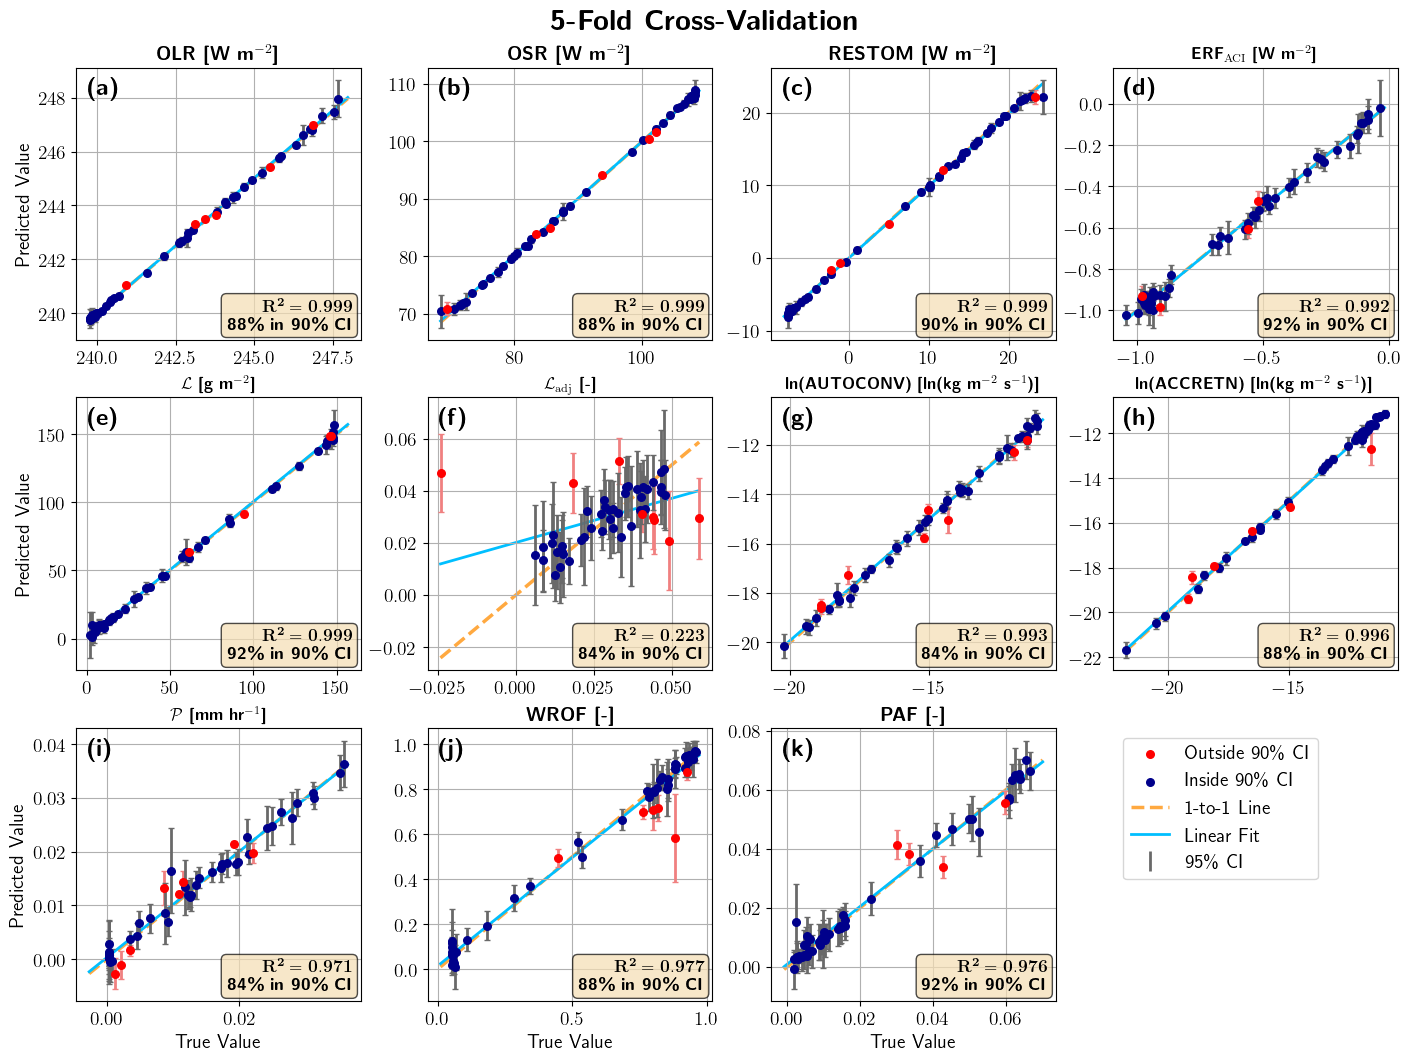

done


In [58]:
# Assume all_true_y, all_pred_y, all_pred_std, and validation_transforms are loaded

# Define ONLY the variables to plot
output_targets = ['OLR_UPWELL_PD', 'OSR_UPWELL_PD','RESTOM_PD', 'ERF_ACI', 
    'LWP_PD',  'LWP_adj',
    'AUTOCONV_PD', 'ACCRETN_PD', 
    'PRECL_PD','WROF_PD', 'PAF_PD', 
]
# Define labels for plotting
labels = {
    'OLR_UPWELL_PD': 'OLR [W m$^{-2}$]',
    'OSR_UPWELL_PD': 'OSR [W m$^{-2}$]',
    'RESTOM_PD': 'RESTOM [W m$^{-2}$]',
    'ERF_ACI': r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]',
    'LWP_PD': r'$\mathcal{L}$ [g m$^{-2}$]', 
    'LWP_adj': r'$\mathcal{L}_{\mathrm{adj}}$ [-]',
    'AUTOCONV_PD': r'ln(AUTOCONV) [ln(kg m$^{-2}$ s$^{-1}$)]',
    'ACCRETN_PD': r'ln(ACCRETN) [ln(kg m$^{-2}$ s$^{-1}$)]',    
    'PRECL_PD': '$\mathcal{P}$ [mm hr$^{-1}$]', 
    'WROF_PD': 'WROF [-]', 'PAF_PD': 'PAF [-]',
}

print("\n" + "="*60)
print("PART 2: PLOTTING FINAL AGGREGATED VALIDATION RESULTS")
print("="*60)
N_OUTPUTS = len(output_targets)
N_COLS = 4
N_ROWS = 3
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(3.5 * N_COLS, 3.5 * N_ROWS), constrained_layout=True)
ax_flat = axes.flatten()
Fontsize = 14
panel_labels = string.ascii_lowercase

for ax in axes[:,0]:
    ax.set_ylabel('Predicted Value', fontsize=Fontsize)
for ax in axes[-1,:]:
    ax.set_xlabel('True Value', fontsize=Fontsize)

#=====================================================
# Begin Loop
#=====================================================
for i, var_name in enumerate(output_targets):
    print(i, var_name)
    ax = ax_flat[i]
    
    y_true = np.array(all_true_y[var_name])
    y_pred = np.array(all_pred_y[var_name])
    y_std = np.array(all_pred_std[var_name])
    
    error_bars = 1.645 * y_std
    
    # --- Perform stats ---
    r2 = linregress(y_true, y_pred).rvalue**2
    
    # --- START: NEW MASKING LOGIC ---
    # 1. Create a boolean mask to identify points inside the CI
    is_within_ci = np.abs(y_true - y_pred) <= error_bars
    percent_within_ci = np.mean(is_within_ci) * 100

    # 2. Separate the data into two groups based on the mask
    y_true_in = y_true[is_within_ci]
    y_pred_in = y_pred[is_within_ci]
    error_bars_in = error_bars[is_within_ci]
    
    y_true_out = y_true[~is_within_ci] # ~ is the "not" operator
    y_pred_out = y_pred[~is_within_ci]
    error_bars_out = error_bars[~is_within_ci]

    # --- Plotting with two colors ---
    # 3. Plot the "out" points first in red
    ax.errorbar(y_true_out, y_pred_out, yerr=error_bars_out, fmt='o', markersize=4, color='lightcoral', 
                ecolor='lightcoral', elinewidth=2, capsize=2)
    ax.scatter(y_true_out, y_pred_out, color='red', s=30, zorder=6, label='Outside 90\% CI')

    # 4. Plot the "in" points on top in blue
    ax.errorbar(y_true_in, y_pred_in, yerr=error_bars_in, fmt='o', markersize=4, color='skyblue', 
                ecolor='dimgrey', elinewidth=2, capsize=2)
    ax.scatter(y_true_in, y_pred_in, color='darkblue', s=30, zorder=5, label='Inside 90\% CI')
    # --- END: NEW MASKING LOGIC ---
    
    # Plot 1-to-1 line
    try:
        lim_min = min(y_true.min(), y_pred.min())
        lim_max = max(y_true.max(), y_pred.max())
        lims = [lim_min, lim_max]
        ax.plot(lims, lims, c='darkorange',ls='dashed', alpha=0.75, lw=2.5, zorder=0, label='1-to-1 Line')
    except ValueError: 
        pass
        
    # Plot linear regression line
    slope, intercept, _, _, _ = linregress(y_true, y_pred)
    reg_line_x = np.array(lims)
    reg_line_y = slope * reg_line_x + intercept
    ax.plot(reg_line_x, reg_line_y, 'deepskyblue', lw=2, zorder=0, label=f'Linear Fit')
    
    # --- Formatting and Annotation (unchanged) ---
    title = labels.get(var_name, var_name)
    ax.set_title(fr'\textbf{{{title}}}', fontsize=Fontsize if len(title) < 25 else Fontsize*0.85, fontweight='bold')
    
    ax.text(0.04, 0.97, rf'\textbf{{({panel_labels[i]})}}', transform=ax.transAxes, fontsize=Fontsize*1.25, 
            fontweight='bold', verticalalignment='top', ha='left')
    
    text_str = (
        r"$\mathbf{R^2 = " + f"{r2:.3f}" + r"}$" + "\n" +
        r"$\textbf{" + f"{percent_within_ci:.0f}" + r"\%\ in\ 90\%\ CI}$"
    )
    ax.text(0.97, 0.03, text_str, 
            transform=ax.transAxes, fontsize=Fontsize*0.9, verticalalignment='bottom',ha='right', 
            bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.7))            
    ax.grid(True)
    ax.tick_params(labelsize=Fontsize)

# --- Legend creation (simplified) ---
legend_ax = ax_flat[N_OUTPUTS]
handles, legend_labels = ax_flat[0].get_legend_handles_labels()
# Manually create a proxy for the error bars since they are drawn in two colors
ci_proxy = plt.errorbar([], [], yerr=1, fmt='none', ecolor='dimgrey', elinewidth=2, capsize=2, label='95\% CI')
handles.append(ci_proxy)
legend_labels.append('95\% CI')
legend_ax.legend(handles=handles, labels=legend_labels, loc='upper left', fontsize=Fontsize)
legend_ax.axis('off')

# Turn off any other remaining unused axes
for j in range(N_OUTPUTS + 1, len(ax_flat)):
    ax_flat[j].set_visible(False)

fig.suptitle(r'\textbf{5-Fold Cross-Validation}', fontsize=Fontsize*1.5)
save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'cross_validation_parity_plots.png'
#plt.savefig(save_path+file_name,dpi=300)
plt.show()
plt.close()
print('done')

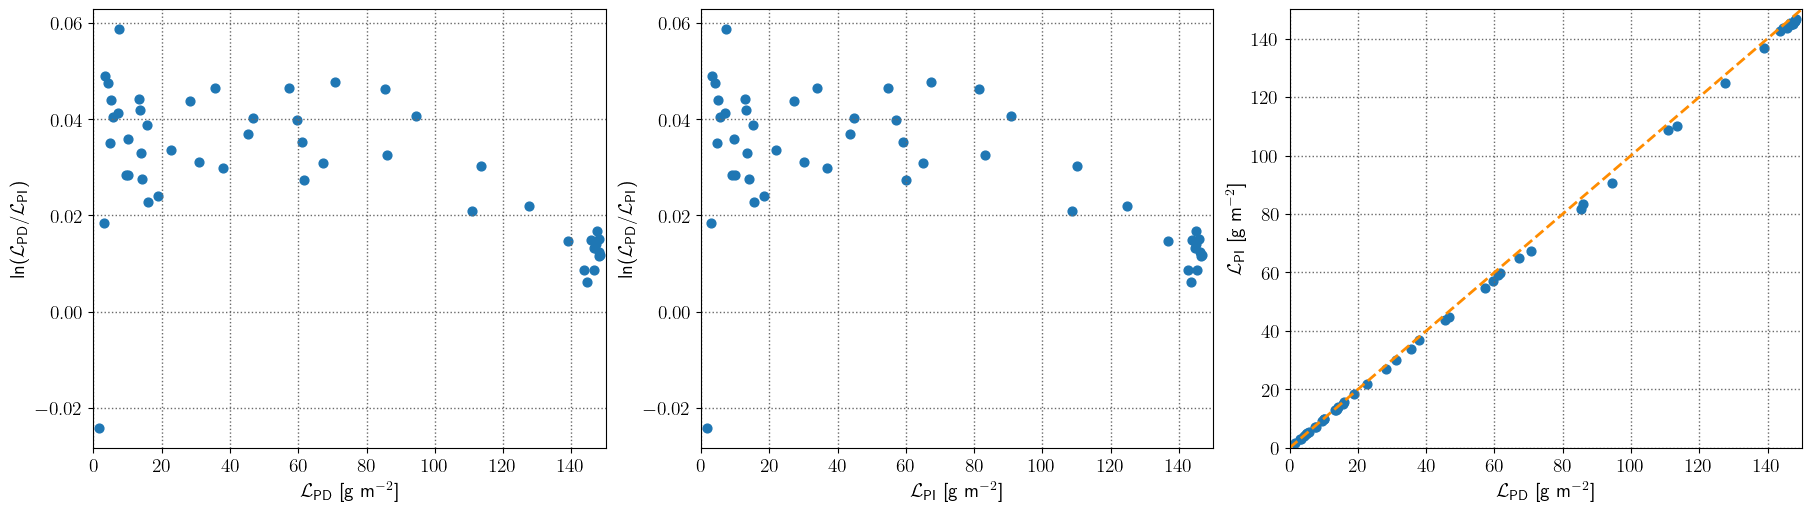

In [41]:
fig = plt.figure(figsize=(18,5),constrained_layout=True)
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
Fontsize=14
axlist = [ax1,ax2,ax3]
for ax in axlist:
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.tick_params(labelsize=Fontsize)
ax1.set_xlim(0,150)
ax2.set_xlim(0,150)
ax3.set_xlim(0,150)
ax3.set_ylim(0,150)

ax1.set_xlabel(r'$\mathcal{L}$\textsubscript{PD} [g m$^{-2}$]',fontsize=Fontsize)
ax2.set_xlabel(r'$\mathcal{L}$\textsubscript{PI} [g m$^{-2}$]',fontsize=Fontsize)
ax1.set_ylabel(r'ln($\mathcal{L}$\textsubscript{PD}/$\mathcal{L}$\textsubscript{PI})',fontsize=Fontsize)
ax2.set_ylabel(r'ln($\mathcal{L}$\textsubscript{PD}/$\mathcal{L}$\textsubscript{PI})',fontsize=Fontsize)
ax3.set_xlabel(r'$\mathcal{L}$\textsubscript{PD} [g m$^{-2}$]',fontsize=Fontsize)
ax3.set_ylabel(r'$\mathcal{L}$\textsubscript{PI} [g m$^{-2}$]',fontsize=Fontsize)

ax1.scatter(df_regime2['LWP_PD'],df_regime2['LWP_adj'],s=40)
ax2.scatter(df_regime2['LWP_PI'],df_regime2['LWP_adj'],s=40)
ax3.scatter(df_regime2['LWP_PD'],df_regime2['LWP_PI'],s=40)

ax3.plot([0,150],[0,150],lw=2,c='darkorange',ls='dashed')


plt.show()
plt.close()

--- Identifying Outliers for LWP_adj ---
Found 6 points outside the 95% CI.
Indices of outlier points: [ 3  7 16 18 20 23]

Original R² (all 50 points): 0.223
Cleaned R² (44 points): 0.744


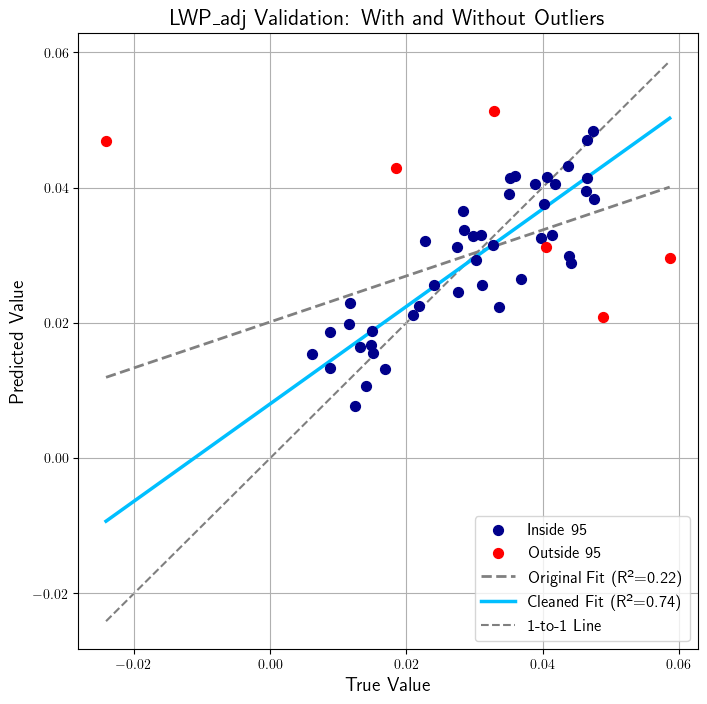


--- Physical Properties of Outlier Points ---
        x_auto      x_accr      LWP_PD      LWP_PI   LWP_adj  GLOBAL_LCC_PD  \
3     0.002381    0.153418  147.974965  146.144485  0.012447       0.010596   
7     0.539279  130.024017   13.462151   12.879763  0.044225       0.001551   
16  530.723315   77.154043    1.724476    1.766597 -0.024132       0.000124   
18    0.005961    0.554028  144.523173  143.640031  0.006129       0.010676   
20    0.028497    0.073056  146.511917  144.596803  0.013158       0.010620   
23  179.105864    0.032240   15.719058   15.119439  0.038893       0.001032   

    GLOBAL_LCC_PI  GLOBAL_LCC_adj  
3        0.010620       -0.002270  
7        0.001380        0.116550  
16       0.000107        0.149899  
18       0.010663        0.001274  
20       0.010584        0.003446  
23       0.000882        0.156897  
CNTL LWP_PD 78.1910750903092
CNTL LWP_PI 76.41189780549738
CNTL LWP_adj 0.023017097271893928
CNTL GLOBAL_LCC_PD 0.010083705707198678
CNTL GLOBAL_LC

In [56]:
# ==============================================================================
# 1. IDENTIFY THE OUTLIER POINTS FOR LWP_adj
# ==============================================================================

var_name = 'LWP_adj'

# Retrieve the cross-validation results for LWP_adj
y_true = np.array(all_true_y[var_name])
y_pred = np.array(all_pred_y[var_name])
y_std = np.array(all_pred_std[var_name])

# Calculate the error bars and identify the points outside the CI
error_bars = 1.96 * y_std
is_within_ci = np.abs(y_true - y_pred) <= error_bars

# Get the indices of the outlier points from the original 50-member set
# The `np.where` function returns a tuple, so we take the first element [0]
outlier_indices = np.where(~is_within_ci)[0]
good_indices = np.where(is_within_ci)[0]

print(f"--- Identifying Outliers for {var_name} ---")
print(f"Found {len(outlier_indices)} points outside the 95% CI.")
print(f"Indices of outlier points: {outlier_indices}")

# ==============================================================================
# 2. RECALCULATE R² AND RE-PLOT WITHOUT OUTLIERS
# ==============================================================================

# Select only the "good" points for the new analysis
y_true_good = y_true[good_indices]
y_pred_good = y_pred[good_indices]

# Recalculate R² on the cleaned data
r2_cleaned = linregress(y_true_good, y_pred_good).rvalue**2

print(f"\nOriginal R² (all 50 points): {linregress(y_true, y_pred).rvalue**2:.3f}")
print(f"Cleaned R² (44 points): {r2_cleaned:.3f}")

# --- Create a new one-panel plot for comparison ---
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the "good" points in blue
ax.scatter(y_true_good, y_pred_good, color='darkblue', s=50, zorder=5, label='Inside 95% CI')
# Plot the "outlier" points in red
ax.scatter(y_true[outlier_indices], y_pred[outlier_indices], color='red', s=50, zorder=6, label='Outside 95% CI (Removed)')

# Plot the original linear fit (all 50 points)
slope_orig, intercept_orig, _, _, _ = linregress(y_true, y_pred)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, slope_orig * np.array(lims) + intercept_orig, 'gray', ls='--', lw=2, label=f'Original Fit (R²={linregress(y_true, y_pred).rvalue**2:.2f})')

# Plot the NEW linear fit (44 points)
slope_cleaned, intercept_cleaned, _, _, _ = linregress(y_true_good, y_pred_good)
ax.plot(lims, slope_cleaned * np.array(lims) + intercept_cleaned, 'deepskyblue', ls='-', lw=2.5, label=f'Cleaned Fit (R²={r2_cleaned:.2f})')

# Plot the 1-to-1 line
ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0, label='1-to-1 Line')

ax.set_title('LWP_adj Validation: With and Without Outliers', fontsize=16)
ax.set_xlabel('True Value', fontsize=14)
ax.set_ylabel('Predicted Value', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True)
plt.show()

# ==============================================================================
# 3. DIAGNOSE THE PHYSICAL PROPERTIES OF THE OUTLIERS
# ==============================================================================
# Assume `df_regime2` is your original dataframe with 50 rows of simulation outputs

# Select the rows from the original dataframe that correspond to the outliers
outlier_df = df_regime2.iloc[outlier_indices]

# Define the diagnostic variables we want to look at
diagnostic_vars = [
    'x_auto',
    'x_accr',
    'LWP_PD', 
    'LWP_PI', # Assuming you have LWP_PI in your dataframe
    'LWP_adj',
    'GLOBAL_LCC_PD', 
    'GLOBAL_LCC_PI', # Assuming you have GLOBAL_LCC_PI
    'GLOBAL_LCC_adj', # Assuming you have GLOBAL_LCC_PI
    
]

# Display the properties of these outlier runs
print("\n--- Physical Properties of Outlier Points ---")
# Use .reindex to ensure the columns are in the desired order
print(outlier_df.reindex(columns=diagnostic_vars))
print('CNTL LWP_PD',df_cntl_regime2['LWP_PD'].iloc[0])
print('CNTL LWP_PI',df_cntl_regime2['LWP_PI'].iloc[0])
print('CNTL LWP_adj',df_cntl_regime2['LWP_adj'].iloc[0])
print('CNTL GLOBAL_LCC_PD',df_cntl_regime2['GLOBAL_LCC_PD'].iloc[0])
print('CNTL GLOBAL_LCC_PI',df_cntl_regime2['GLOBAL_LCC_PI'].iloc[0])
print('CNTL GLOBAL_LCC_adj',df_cntl_regime2['GLOBAL_LCC_adj'].iloc[0])

In [ ]:
df_cntl['

# Step 3: Train and save final production emulators trained on all 50 members

In [71]:
SAVE_PRODUCTION_EMULATORS = True # Set to True for the final training run

if SAVE_PRODUCTION_EMULATORS:
    print("\n" + "="*60)
    print("PART 3: TRAINING AND SAVING FINAL PRODUCTION EMULATORS ON ALL 50 MEMBERS")
    print("="*60)
    production_transforms = {}

    for i, var_name in enumerate(output_targets):
        print(f"  -> Training final emulator for: {var_name}")
        y_target_full = Y_full[:, i]
        
        if var_name in log_transform_vars:
            y_to_train = np.log(y_target_full + 1e-20)
            production_transforms[var_name] = 'log'
        else:
            y_to_train = y_target_full
            production_transforms[var_name] = 'linear'

        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15, random_state=42, normalize_y=True)
        
        # Train on the FULL globally scaled X data
        gp.fit(X_full_scaled, y_to_train)
        # Validate the skill using the R-squared score
        score = gp.score(X_full_scaled, y_to_train)
        print(f"    Emulator skill (R²): {score:.4f}")
        
        joblib.dump(gp, f'{emulators_dir}/gp_production_{var_name}.joblib')

    joblib.dump(production_transforms, f'{emulators_dir}/production_transforms.joblib')
    print("\n--- Production emulators and transform info are saved. ---")
else:
    print("\nSkipping training of final production emulators (SAVE_PRODUCTION_EMULATORS=False).")


PART 3: TRAINING AND SAVING FINAL PRODUCTION EMULATORS ON ALL 50 MEMBERS
  -> Training final emulator for: LWP_PD
    Emulator skill (R²): 1.0000
  -> Training final emulator for: CDNC_PD
    Emulator skill (R²): 0.9998
  -> Training final emulator for: REFF_PD


/glade/work/mckenna/conda_envs/esem/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


    Emulator skill (R²): 0.9997
  -> Training final emulator for: GLOBAL_LCC_PD
    Emulator skill (R²): 0.9993
  -> Training final emulator for: WROF_PD
    Emulator skill (R²): 0.9993
  -> Training final emulator for: PAF_PD
    Emulator skill (R²): 0.9953
  -> Training final emulator for: AUTOCONV_PD
    Emulator skill (R²): 0.9982
  -> Training final emulator for: ACCRETN_PD
    Emulator skill (R²): 0.9997
  -> Training final emulator for: LWP_adj
    Emulator skill (R²): 0.9569
  -> Training final emulator for: CDNC_adj
    Emulator skill (R²): 0.9999
  -> Training final emulator for: REFF_adj
    Emulator skill (R²): 0.9758
  -> Training final emulator for: GLOBAL_LCC_adj
    Emulator skill (R²): 0.9953
  -> Training final emulator for: WROF_adj
    Emulator skill (R²): 0.9893
  -> Training final emulator for: PAF_adj
    Emulator skill (R²): 0.8175
  -> Training final emulator for: AUTOCONV_adj
    Emulator skill (R²): 0.6355
  -> Training final emulator for: ACCRETN_adj
    Emu

# Perform a test of the emulators

In [75]:
VARS_TO_TEST = ['OLR_UPWELL_PD', 'OSR_UPWELL_PD','RESTOM_PD', 'ERF_ACI',  'LWP_PD',  'LWP_adj','AUTOCONV_PD', 'ACCRETN_PD', 'PRECL_PD','WROF_PD', 'PAF_PD', ]

# Define observation targets
observation_targets = {
    'OLR_UPWELL_PD': df_cntl_regime2['OLR_UPWELL_PD'].iloc[0],
    'OSR_UPWELL_PD': df_cntl_regime2['OSR_UPWELL_PD'].iloc[0],
    'RESTOM_PD': df_cntl_regime2['RESTOM_PD'].iloc[0],
    'ERF_ACI': df_cntl_regime2['ERF_ACI'].iloc[0],
    'LWP_PD': df_cntl_regime2['LWP_PD'].iloc[0],
    'LWP_adj': df_cntl_regime2['LWP_adj'].iloc[0],
    'AUTOCONV_PD': df_cntl_regime2['AUTOCONV_PD'].iloc[0],
    'ACCRETN_PD': df_cntl_regime2['ACCRETN_PD'].iloc[0],
    'PRECL_PD': df_cntl_regime2['PRECL_PD'].iloc[0],
    'WROF_PD': df_cntl_regime2['WROF_PD'].iloc[0],
    'PAF_PD': df_cntl_regime2['PAF_PD'].iloc[0],
}

# --- Load all necessary helper files ---
emulators_dir = './emulators_production'
transforms = joblib.load(f'{emulators_dir}/production_transforms.joblib')
global_x_scaler = joblib.load(f'{emulators_dir}/global_x_scaler.joblib')

# --- Define the single test point ---
theta_unscaled = np.array([1.0, 1.0]).reshape(1, -1)

# Loop through each variable to test
for var_name in VARS_TO_TEST:
    print("\n" + "="*60)
    print(f"--- TESTING PRODUCTION EMULATOR FOR: {var_name} ---")
    print("="*60)

    emulator = joblib.load(f'{emulators_dir}/gp_production_{var_name}.joblib')
    print("Emulator loaded.")
    
    # --- Step 1: Apply the correct and consistent input transformation ---
    # This pipeline is now the same for ALL emulators.
    theta_log10 = np.log10(theta_unscaled)
    theta_scaled = global_x_scaler.transform(theta_log10)
    
    print(f"Input to emulator (scaled log10 space): {theta_scaled[0]}")

    # --- Step 2: Get the prediction and apply inverse transform if needed ---
    prediction_raw = emulator.predict(theta_scaled)[0]
    transform_type = transforms.get(var_name, 'linear')
    
    if transform_type == 'log':
        print("Prediction is in ln-space. Applying np.exp()...")
        prediction_physical = np.exp(prediction_raw)
    else:
        prediction_physical = prediction_raw

    # --- Step 3: Compare to the observation ---
    observation = observation_targets[var_name]
    difference = prediction_physical - observation
    percent_error = abs(difference / observation) * 100 if observation != 0 else np.inf

    print("\n--- RESULTS ---")
    print(f"Raw Prediction (from GP): {prediction_raw:.4f}")
    print(f"Final Physical Prediction: {prediction_physical:.4f}")
    print(f"Observation Target:        {observation:.4f}")
    print(f"Difference:                {difference:.4f}")
    print(f"Percent Error:             {percent_error:.2f}%")



--- TESTING PRODUCTION EMULATOR FOR: OLR_UPWELL_PD ---
Emulator loaded.
Input to emulator (scaled log10 space): [0.50062741 0.49665408]

--- RESULTS ---
Raw Prediction (from GP): 240.9854
Final Physical Prediction: 240.9854
Observation Target:        241.0307
Difference:                -0.0453
Percent Error:             0.02%

--- TESTING PRODUCTION EMULATOR FOR: OSR_UPWELL_PD ---
Emulator loaded.
Input to emulator (scaled log10 space): [0.50062741 0.49665408]

--- RESULTS ---
Raw Prediction (from GP): 97.6540
Final Physical Prediction: 97.6540
Observation Target:        97.8993
Difference:                -0.2453
Percent Error:             0.25%

--- TESTING PRODUCTION EMULATOR FOR: RESTOM_PD ---
Emulator loaded.
Input to emulator (scaled log10 space): [0.50062741 0.49665408]

--- RESULTS ---
Raw Prediction (from GP): 1.7685
Final Physical Prediction: 1.7685
Observation Target:        1.4813
Difference:                0.2872
Percent Error:             19.39%

--- TESTING PRODUCTION EM

# Read in LH Sampling file, add mechanism denial experiments, and visualize

In [48]:
pre_path = '/glade/u/home/mckenna/work/ppe_pre/'
filename = 'e3sm_lhs_samples.csv'
df = pd.read_csv(pre_path+filename)
#df
new_rows_data_begin = [
        {'Sample #':0, 'Accretion Factor':1, 'Autoconversion Factor':1},
]
new_rows_data_end = [
    {'Sample #':51, 'Accretion Factor':0, 'Autoconversion Factor':1},
    {'Sample #':52, 'Accretion Factor':1, 'Autoconversion Factor':0},
    {'Sample #':53, 'Accretion Factor':0, 'Autoconversion Factor':0},
]
df_to_add_begin = pd.DataFrame(new_rows_data_begin)
df_to_add_end = pd.DataFrame(new_rows_data_end)
df_updated = pd.concat([df_to_add_begin,df,df_to_add_end],ignore_index=True)
#df_updated

In [49]:
#df_updated

In [58]:
fig, ax = plt.subplots(figsize=(6,5))
MIN_FACTOR = 1/1024
MAX_FACTOR = 1024
N_SAMPLES = 50
Fontsize=14
# Create the scatter plot
ax.scatter(
    df_updated['Autoconversion Factor'][0:50],
    df_updated['Accretion Factor'][0:50],
    c='royalblue',
    edgecolor='k',
    alpha=0.8,
    s=50
)

# Set axes to log scale to correctly visualize the distribution
ax.set_xscale('log')
ax.set_yscale('log')

# Set limits to match the specified range
ax.set_xlim(MIN_FACTOR, MAX_FACTOR)
ax.set_ylim(MIN_FACTOR, MAX_FACTOR)

# Add reference lines at factor=1 (the baseline/no-change value)
ax.axhline(1, color='grey', linestyle='--', linewidth=1.5, label='CNTL')
ax.axvline(1, color='grey', linestyle='--', linewidth=1.5)

# Add grid lines that correspond to the LHS bins to show the stratified sampling
# Note: These are not the exact bin boundaries but illustrate the concept
ax.grid(True, which="both", ls="--", linewidth=0.5)

# Labels and Title
ax.set_title(f'2D Parameter Space of {N_SAMPLES} Latin Square Samples', fontsize=Fontsize*1.25, pad=20)
ax.set_ylabel('Accretion Rate Multiplicative Factor (x_accr)', fontsize=Fontsize)
ax.set_xlabel('Autoconversion Rate Multiplicative Factor (x_auto)', fontsize=Fontsize)
ax.legend(fontsize=Fontsize)
ax.set_aspect('equal', adjustable='box') # Ensure the plot is square
ax.tick_params(labelsize=Fontsize)

save_path = '/glade/u/home/mckenna/scratch/figures/pnas_paper/'
file_name = f'Latin_square_xauto_xaccr.png'
plt.savefig(save_path+file_name,dpi=300)
#plt.show()
plt.close()
print('done')

done
